In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("giripujar/hr-analytics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hr-analytics' dataset.
Path to dataset files: /kaggle/input/hr-analytics


In [ ]:
import pandas as pd
df = pd.read_csv('/content/sample_data/HR_comma_sep.csv')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


# Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


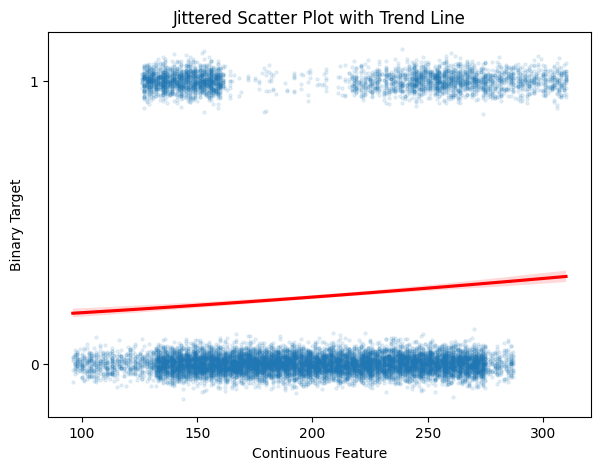

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
jitter = np.random.normal(0, 0.03, size=len(df))
y_jittered = df['left'] + jitter

plt.figure(figsize=(7, 5))
# s=5 makes points smaller, alpha=0.1 handles the 15k high density
plt.scatter(df['average_montly_hours'], y_jittered, alpha=0.1, s=5)

# 2. Overlay a logistic trend line to see the actual relationship
sns.regplot(x=df['average_montly_hours'], y=df['left'], data=df,
            scatter=False, logistic=True, color='red')

plt.yticks([0, 1])
plt.ylabel('Binary Target')
plt.xlabel('Continuous Feature')
plt.title('Jittered Scatter Plot with Trend Line')
plt.show()

In [ ]:
f = df.query('left == 0')
f.head(50)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
2000,0.58,0.74,4,215,3,0,0,0,sales,low
2001,0.82,0.67,2,202,3,0,0,0,sales,low
2002,0.45,0.69,5,193,3,0,0,0,sales,low
2003,0.78,0.82,5,247,3,0,0,0,sales,low
2004,0.49,0.60,3,214,2,0,0,0,sales,low
2005,0.36,0.95,3,206,4,0,0,0,sales,low
2006,0.54,0.37,2,176,2,0,0,0,sales,low
2007,0.99,0.91,5,136,4,0,0,0,sales,low
2008,0.50,0.75,6,127,3,0,0,0,sales,low
2009,0.74,0.64,4,268,3,0,0,0,sales,low


In [ ]:
left = df[df['left'] == 1]
stayed = df[df['left'] == 0]

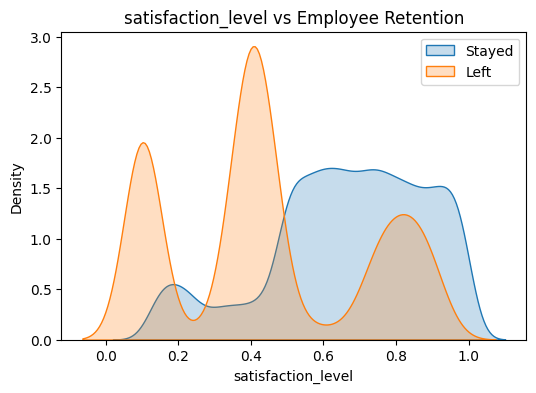

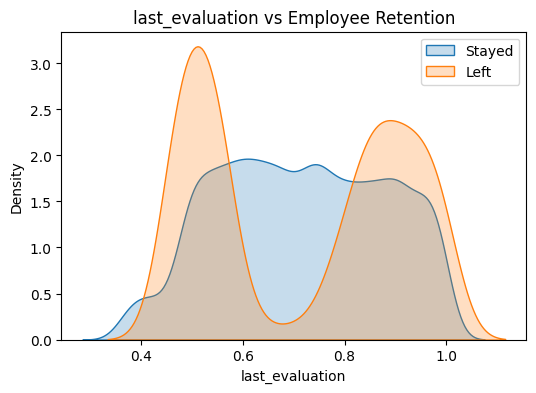

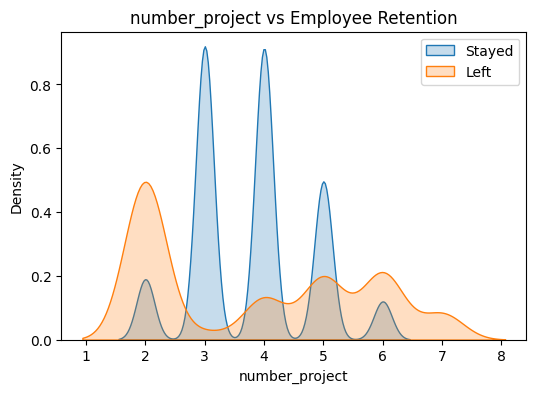

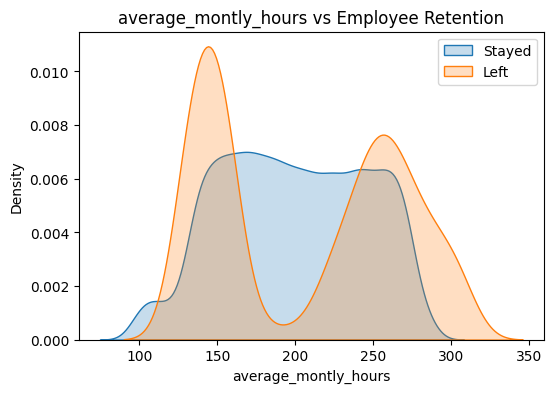

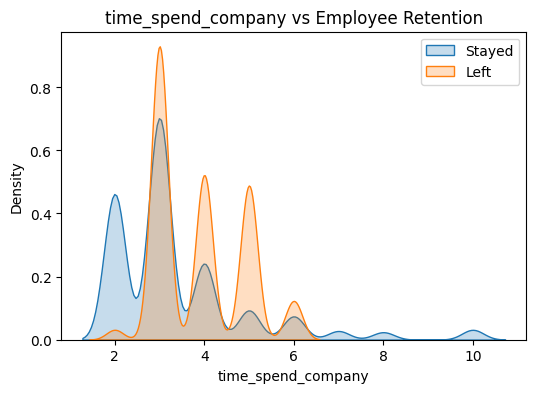

In [ ]:
numerical_features = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company'
]

for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(stayed[feature], label='Stayed', fill=True)
    sns.kdeplot(left[feature], label='Left', fill=True)
    plt.title(f"{feature} vs Employee Retention")
    plt.legend()
    plt.show()

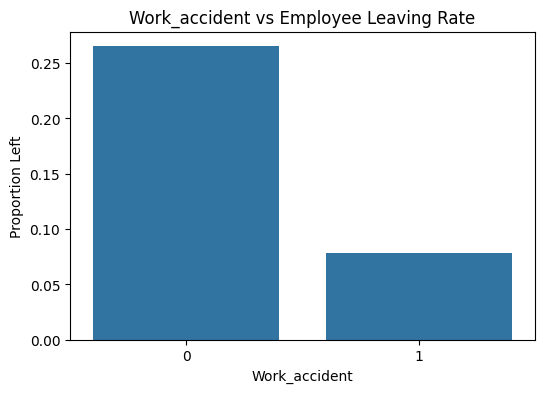

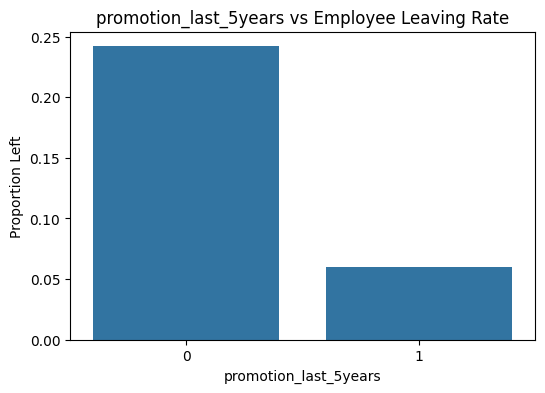

In [ ]:
categorical_features = [
    'Work_accident',
    'promotion_last_5years'
]

for feature in categorical_features:
    plt.figure(figsize=(6,4))

    temp = df.groupby(feature)['left'].mean().reset_index()

    sns.barplot(x=feature, y='left', data=temp)
    plt.title(f"{feature} vs Employee Leaving Rate")
    plt.ylabel("Proportion Left")

    plt.show()


In [ ]:
df[df['Work_accident'] == 1].count()

,0
satisfaction_level,2169
last_evaluation,2169
number_project,2169
average_montly_hours,2169
time_spend_company,2169
Work_accident,2169
left,2169
promotion_last_5years,2169
Department,2169
salary,2169


In [ ]:
df.query('Work_accident == 1 and left == 1').count()

,0
satisfaction_level,169
last_evaluation,169
number_project,169
average_montly_hours,169
time_spend_company,169
Work_accident,169
left,169
promotion_last_5years,169
Department,169
salary,169


From the EDA, it is calculated, that employee salary, and satisfaction level has linear relationship. Incase of average Monthly Hours, it has non - linear relationship (U).

# Impact of Employee Salary on Retention

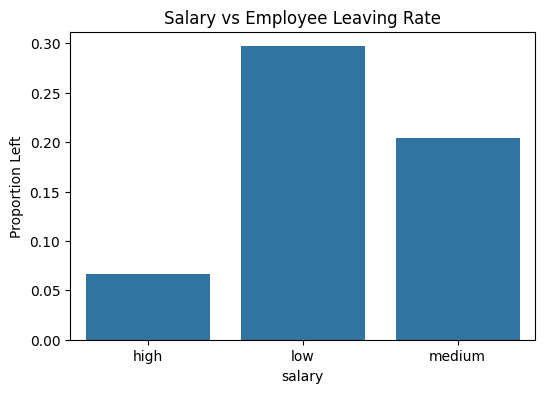

In [ ]:
plt.figure(figsize = (6,4))
temp = df.groupby('salary')['left'].mean().reset_index()
sns.barplot(x = 'salary', y = 'left', data = temp)
plt.title('Salary vs Employee Leaving Rate')
plt.ylabel('Proportion Left')
plt.show()

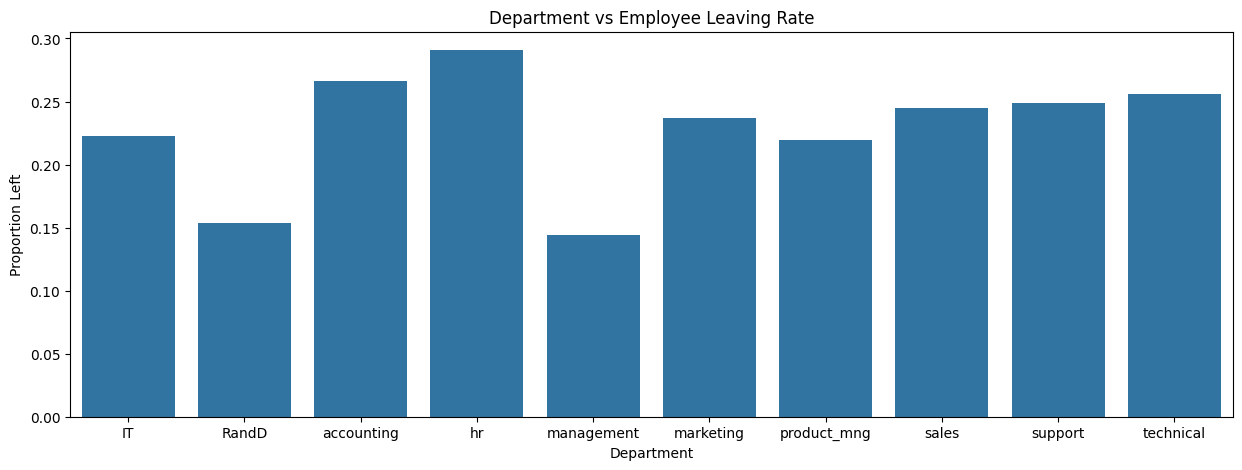

In [ ]:

plt.figure(figsize=(15,5))
temp = df.groupby('Department')['left'].mean().reset_index()
temp.head(20)
sns.barplot(x = 'Department', y = 'left', data = temp)
plt.title('Department vs Employee Leaving Rate')
plt.ylabel('Proportion Left')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
dummies = pd.get_dummies(df['salary'], dtype = int)
dummies.head()

,high,low,medium
0,0,1,0
1,0,0,1
2,0,0,1
3,0,1,0
4,0,1,0


In [ ]:
merged = pd.concat([df, dummies], axis = 'columns')
merged.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,sales,low,0,1,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,0,0,1
2,0.11,0.88,7,272,4,0,1,0,sales,medium,0,0,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,0,1,0
4,0.37,0.52,2,159,3,0,1,0,sales,low,0,1,0


In [77]:
merged['hours_squared'] = merged['average_montly_hours'] ** 2
merged['projects_squared'] = merged['number_project'] ** 2

In [88]:
x = merged[['satisfaction_level','average_montly_hours', 'number_project', 'hours_squared', 'projects_squared', 'time_spend_company', 'low', 'medium']]
# x = df[['satisfaction_level', 'salary']]
y = df['left']

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
xtrain, xtest, ytrain, ytest = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

In [109]:
model = LogisticRegression(max_iter = 1000, class_weight='balanced')
model.fit(xtrain, ytrain)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [110]:
model.score(xtest, ytest)

0.8123333333333334

In [111]:
model.predict(xtest)[:10]

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [112]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(xtest)
confusion_matrix(ytest, y_pred)

array([[1887,  407],
       [ 156,  550]])

# Using Threshold 0.4 to Increase the number of TP and Decrease the number of FN. Because finding the number of person who leaves is important than who stays.

In [113]:
y_prob = model.predict_proba(xtest)[:, 1]

# change threshold
threshold = 0.4
y_pred_new = (y_prob >= threshold).astype(int)

from sklearn.metrics import confusion_matrix
confusion_matrix(ytest, y_pred_new)

array([[1769,  525],
       [ 102,  604]])

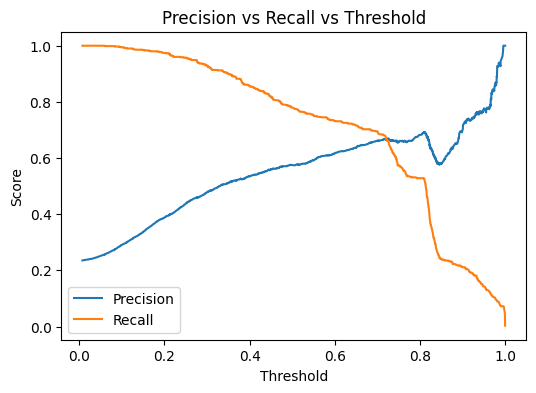

In [114]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

yprob = model.predict_proba(xtest)[:,1]
precision, recall, thresholds = precision_recall_curve(ytest, yprob)
plt.figure(figsize = (6,4))
plt.plot(thresholds, precision[:-1], label = "Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()